# Initialize

## Imports and Definitions

In [12]:
import matplotlib.pyplot as plt
import torch
import os
from pathlib import Path
from importlib import reload
import numpy as np

import glori.settings.paths as paths

In [13]:
mm = 1 / 25.4  # mm in inches
fig_width = 90 * mm
# plt.rcParams.update({"font.size": 5})
plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update(
    {
        "figure.constrained_layout.use": True,
        "figure.dpi": 300,
        "font.family": "Nimbus Roman",
        "font.size": 4.5,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Nimbus Roman",
        "mathtext.it": "Nimbus Roman:italic",
        "mathtext.bf": "Nimbus Roman:bold",
        "mathtext.cal": "Nimbus Roman:italic",
        "text.usetex": False,
        "legend.frameon": False,
    }
)

# Output settings
output_parent = paths.ANALYSIS_PARENT / "paper_plots_III_defense"
savefig_kw = dict(dpi=300, bbox_inches="tight", pad_inches=0)

# Dataset Generation Plots

## Imports, Definitions and Loads

Required imports and functions

In [15]:
from glori.plotting.maps import plot_sky_map
from glori.data.load import load_fits_image, load_mosaic

from glori.data.obs.micromaps.utils import (
    get_micromap_centers,
    get_micromaps,
    context_map_by_wcs,
    single_micromap_cutout,
    reduce_context_map,
    filter_catalog_by_wcs,
)
import pandas as pd


# Convenience function for loading mosaic names
# with control over random seed, number and max beam size
def load_mosaic_names(n_mosaics=1, seed=None, max_beam_arcsec=None):
    # Get list of mosaics based on directory contents
    mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])

    # Filter by max beam if specified
    if max_beam_arcsec is not None:
        # Load pointing info, which includes beam sizes
        pointing_info_df = pd.read_csv(
            paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
        )
        # Select good pointings, i.e. pointings with beam <= max_beam_arcsec
        good_pointings = np.array(
            pointing_info_df.index[
                pointing_info_df["Beam"] <= np.round(max_beam_arcsec / 3600, 5)
            ],
            dtype=np.str_,
        )
        # Filter mosaics by good pointings
        select_idxs = np.argwhere([p in good_pointings for p in mosaic_list]).flatten()
        mosaic_list = [mosaic_list[i] for i in select_idxs]
        # Pick randomly from remaining mosaics
        np.random.seed(seed)
        mosaics = [np.random.choice(mosaic_list) for _ in range(n_mosaics)]
        return mosaics

Settings

In [16]:
max_beam_arcsec = 6
seed = 42

# Output settings
output_dir = output_parent / "Dataset_generation"
if not output_dir.exists():
    output_dir.mkdir(parents=True)

Load catalog

In [17]:
# Load LoTSS DR3 catalog
from glori.data.load import load_lotss_catalog

lotss_cat = load_lotss_catalog(
    select_cols=[
        "Source_Name",
        "RA",
        "DEC",
        "Total_flux",
        "Peak_flux",
        "Maj",
        # "Mosaic_ID",
    ]
)

Load pixel scaler

In [18]:
from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

## Mosaic tiling plots

In [ ]:
from glori.plotting.images import plot_image_grid
from glori.data.obs.micromaps.utils import (
    get_micromap_centers,
    get_optimal_micromap_centers,
)
from glori.plotting.maps import plot_sky_map

# Size that the model is trained with, i.e. half the cutout size
image_sizes = [
    # 256,
    512,
]

mosaics = ["P168+15"]  # , "P277+00", "P070+37"]
for mosaic in mosaics:
    print(f"Selected mosaic: {mosaic}")

    map_arr, wcs = load_mosaic(mosaic)

    for image_size in image_sizes:
        micromap_size = image_size * 2
        spacing = 1
        centers = get_optimal_micromap_centers(map_arr, micromap_size, spacing=spacing)
        p = np.flip(centers, axis=1)

        map_arr_scaled = scaler.scale(map_arr)
        absmax = np.nanmax(np.abs(map_arr_scaled))

        fig, ax, _ = plot_sky_map(
            np.clip(map_arr_scaled, 0, None),
            wcs=wcs,
            size=(fig_width / 2,) * 2,
            norm_quantile=0.9999,
            cbar=False,
            scalebar_color="black",
            # cmap='bwr',
        )

        # For testing, this is quicker:
        # fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
        # im = ax.imshow(np.clip(map_arr_scaled, 0, None), origin="lower")

        ax.scatter(*p.T, s=0.5, color="red")

        # Draw square patches around the micromap centers
        for center in p:
            rect = plt.Rectangle(
                center - micromap_size / 2,
                micromap_size,
                micromap_size,
                linewidth=0.75,
                ls="-",
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)

        ax.axis("off")

        fig.savefig(
            output_dir / f"cutout_tiling_{mosaic}_{micromap_size}px.pdf",
            **savefig_kw,
        )

        fig.show()

        micromaps, _, _ = get_micromaps(
            map_arr_scaled, micromap_size, spacing=spacing, centers=centers, wcs=wcs
        )
        fig, axs = plot_image_grid(
            micromaps[:25],
            n_cols=5,
            n_rows=5,
            origin="lower",
        )
        fig.savefig(
            output_dir / f"cutout_tiling_{mosaic}_{micromap_size}px_cutout_grid.pdf",
            **(savefig_kw | dict(dpi=100)),
        )

        fig.show()

## Image and Context Example Plots

In [11]:
from glori.data.obs.micromaps.utils import (
    context_map_by_wcs,
    reduce_context_map,
    fill_nan_pixels,
)

In [19]:
# Load mosaic image
mosaic = "P168+15"
map_arr, wcs = load_mosaic(mosaic)

# Load context
ctxt_map, _ = context_map_by_wcs(wcs, lotss_cat, scale_output=False)

# Get cutouts
micromap_size = 1024
map_arr_scaled = scaler.scale(map_arr)
mmaps, centers, wcss = get_micromaps(map_arr_scaled, micromap_size, wcs=wcs)

Micromaps: 100%|██████████| 48/48 [00:00<00:00, 111.48micromap/s]


In [20]:
# Pick one as example
i_mmap = 30
mmap = mmaps[i_mmap]
center = centers[i_mmap]
wcs_mmap = wcss[i_mmap]

# Get context
ctxt = single_micromap_cutout(
    ctxt_map.transpose(1, 2, 0),
    micromap_size,
    center,
)[
    0
].transpose(2, 0, 1)
ctxt_ext = single_micromap_cutout(
    ctxt_map.transpose(1, 2, 0),
    micromap_size * 2,
    center,
)[0].transpose(2, 0, 1)

# Reduce them for plotting
f_downscale = 16
ctxt = reduce_context_map(ctxt, f_downscale=f_downscale)
ctxt_ext = reduce_context_map(ctxt_ext, f_downscale=f_downscale)

# Blank center of extended context map
if False:
    r_inner = ctxt_ext.shape[-1] // 4
    ctxt_ext[
        :,
        r_inner:-r_inner,
        r_inner:-r_inner,
    ] *= 0

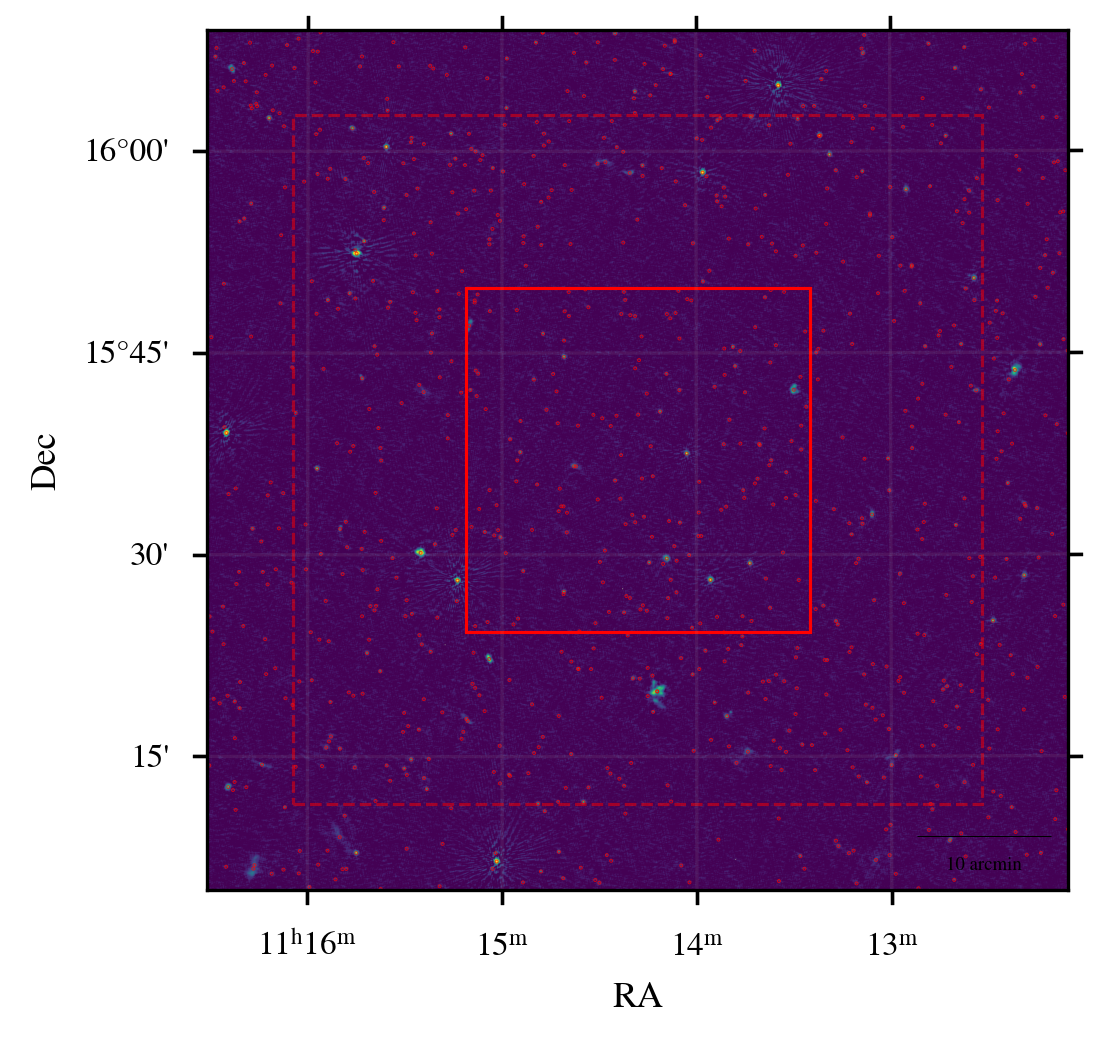

In [21]:
# Plot surroundings of micromap
mosaic_patch, wcs_patch = single_micromap_cutout(
    map_arr_scaled, int(micromap_size * 2.5), center, wcs=wcs
)
patch_cat = filter_catalog_by_wcs(lotss_cat, wcs_patch)
amax = np.nanmax(np.abs(mosaic_patch))
# mosaic_patch_scaled = scaler.scale(mosaic_patch)

from astropy.coordinates import SkyCoord

fig, ax, _ = plot_sky_map(
    np.clip(mosaic_patch, 0, mmap.max()),
    wcs=wcs_patch,
    size=(fig_width, fig_width),
    norm_quantile=None,
    cbar=False,
    scalebar_color="black",
    cmap="viridis",
)

# get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

marker_color = "red"
# marker_color = plt.get_cmap("viridis")(0.75)

ax.scatter_coord(
    SkyCoord(patch_cat["RA"], patch_cat["DEC"], unit="deg"),
    s=2,
    edgecolor=marker_color,
    facecolor="none",
    alpha=0.7,
    marker=".",
)

# Square around center
rect = plt.Rectangle(
    (
        mosaic_patch.shape[0] / 2 - micromap_size / 2,
        mosaic_patch.shape[1] / 2 - micromap_size / 2,
    ),
    micromap_size,
    micromap_size,
    linewidth=0.75,
    ls="-",
    edgecolor=marker_color,
    facecolor="none",
)
ax.add_patch(rect)

rect = plt.Rectangle(
    (
        mosaic_patch.shape[0] / 2 - micromap_size,
        mosaic_patch.shape[1] / 2 - micromap_size,
    ),
    2 * micromap_size,
    2 * micromap_size,
    linewidth=0.75,
    ls="--",
    edgecolor=marker_color,
    facecolor="none",
    alpha=0.5,
)
ax.add_patch(rect)

# Set previous axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Save
fig.savefig(
    output_dir / f"micromap_surroundings_{mosaic}_idx{i_mmap}.pdf",
    **savefig_kw,
)

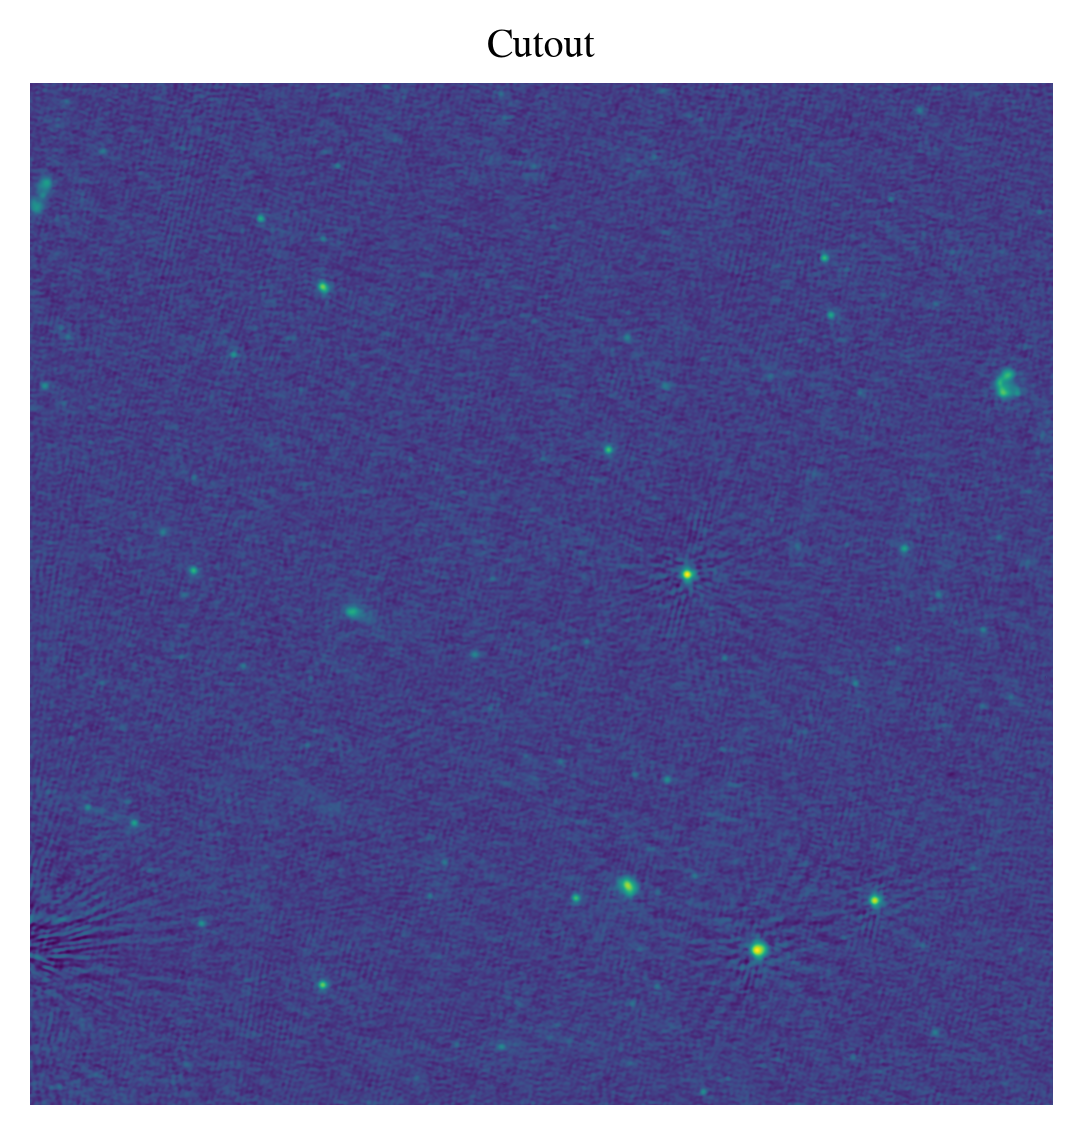

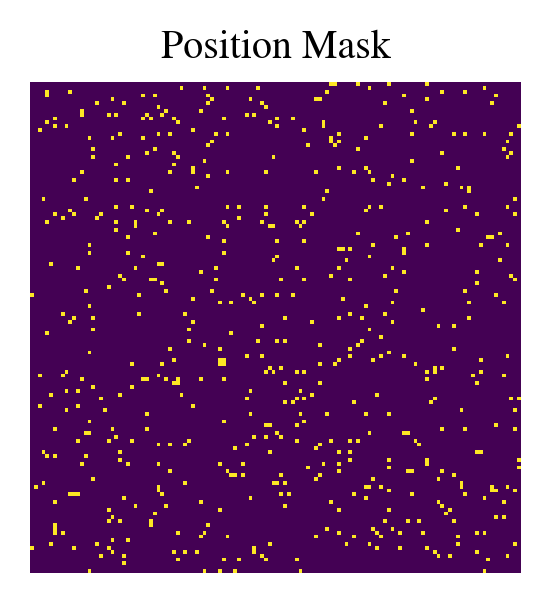

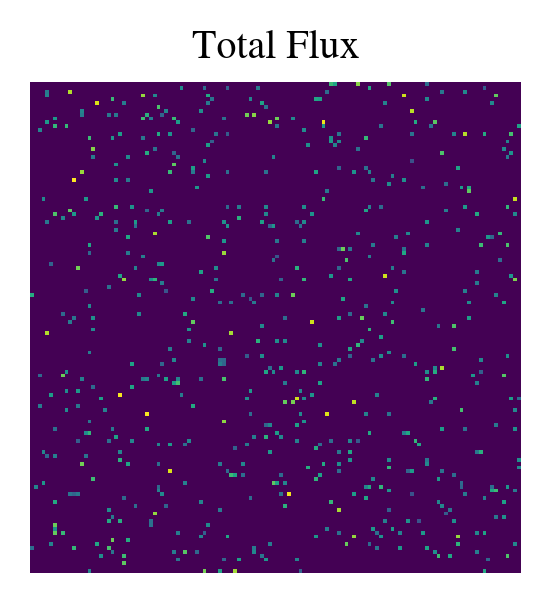

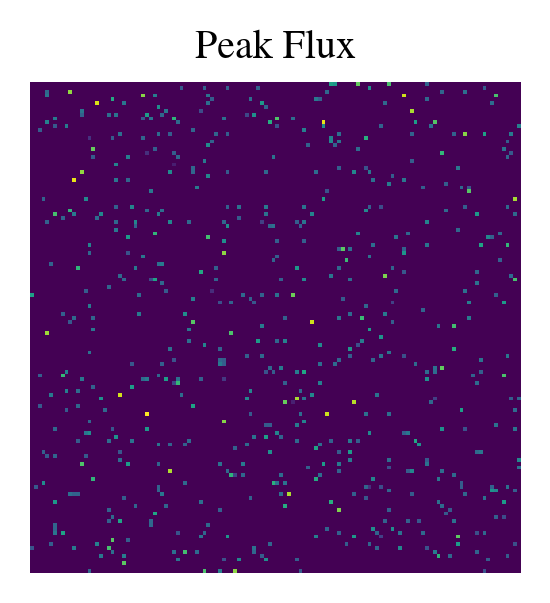

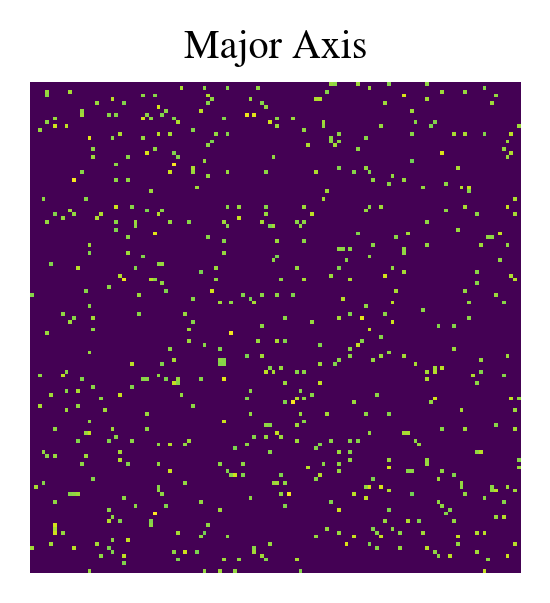

In [24]:
# Plot micromap cutout
fig, ax = plot_image_grid(
    # [np.clip(mmap, 0, None)],
    [mmap],
    figsize=(fig_width, fig_width * 1.2),
    origin="lower",
)

# Set title
ax.set_title("Cutout")

# Save
fig.savefig(
    output_dir / f"micromap_cutout_{mosaic}_idx{i_mmap}.pdf",
    **savefig_kw,
)


def log1p_n(x, n):
    for _ in range(n):
        x = np.log1p(x)
    return x


# Plot context
for ctxt_arr in [ctxt_ext]:
    titles = ["Position Mask", "Total Flux", "Peak Flux", "Major Axis"]
    for i, ch in enumerate(ctxt_arr):
        fig, ax = plot_image_grid(
            [log1p_n(ch, 4)],
            n_cols=1,
            figsize=(fig_width / 2, fig_width * 1.2 / 2),
            origin="lower",
        )
        title = titles[i]

        ax.set_title(title)

        # Save
        size_label = "normal" if ctxt_arr is ctxt else "extended"
        fig.savefig(
            output_dir
            / f"micromap_context_{size_label}_{mosaic}_idx{i_mmap}_{title.replace(' ', '_')}.pdf",
            **savefig_kw,
        )

# Pixel Scaling Plots

Load scaler

In [ ]:
# Load scaler
from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

## Pixel Distributions

Load example pixels

In [ ]:
# Load pixel data
import h5py

px_file = paths.LOFAR_DATA_PARENT / "random_pixels.h5"
with h5py.File(px_file, "r") as f:
    pixel_data = np.array(f["pixels"][:])
    pass

Plot Histograms

In [ ]:
from glori.plotting.utils import auto_log_bins
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# General settings
n_bins = 75
hist_kw = dict(histtype="step", lw=1, color=plt.get_cmap("viridis")(0.2), log=True)
fontsize = "xx-large"

# Create figure
fig, (ax1, ax2) = plt.subplots(
    # 2, 1, figsize=(fig_width, fig_width * 1.5), constrained_layout=True
    1,
    2,
    figsize=(fig_width * 2, fig_width * 2 / 3),
    constrained_layout=True,
)

# Plot original pixel value distribution in top row
bins = np.linspace(-0.01, 0.05, n_bins)
ax1.hist(pixel_data.ravel(), bins=bins, **hist_kw, label="Original Pixels")

# Inset: full range
ax1_inset = ax1.inset_axes([0.68, 0.68, 0.3, 0.3])
ax1_inset.hist(pixel_data.ravel(), bins=n_bins, **hist_kw)
ax1_inset.tick_params(labelsize=6)

# Top axis settings
ax1.set_xlabel("Original pixel values (Jy/Beam)", fontsize=fontsize)
ax1.legend(
    # loc=(0.6, 0.45)
    loc="center right"
)

# Plot scaled pixel value distribution in bottom row
px_scaled = scaler.scale(pixel_data.ravel())
x_bin_limit = 12.5
bins_sc = np.linspace(-x_bin_limit, x_bin_limit, n_bins)
cts, _, _ = ax2.hist(px_scaled, bins=bins_sc, **hist_kw, label="Scaled Pixels")

# Plot gaussian
x_gaus = np.linspace(-x_bin_limit, x_bin_limit, 1000)
gaus = cts.max() * np.exp(-0.5 * x_gaus**2)
ax2.plot(x_gaus, gaus, color="tab:orange", lw=1, alpha=0.5, label="Gaussian")

# Inset: full range
ax2_inset = ax2.inset_axes([0.68, 0.68, 0.3, 0.3])
ax2_inset.hist(px_scaled, bins=n_bins, **hist_kw)
ax2_inset.tick_params(labelsize=6)

# Bottom axis settings
ax2.set_ylim(1e3, np.exp(1.025 * np.log(cts.max())))
ax2.set_xlabel("Scaled pixel values (a.u.)", fontsize=fontsize)
ax2.legend(loc="upper left")

# Add shared x-label for top row using fig.text()
# fig.supylabel("Count", fontsize=fontsize)
ax1.set_ylabel("Count", fontsize=fontsize)
# ax2.set_ylabel("Count", fontsize=fontsize)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

fig.show()

Save figure

In [ ]:
fig.savefig(output_parent / "pixel_value_distributions.pdf", **savefig_kw)
fig.show()

## Example images

Load mosaic image, plot Preview:

In [ ]:
from glori.data.load import load_mosaic, list_mosaics
from glori.plotting.images import plot_image_grid
from skimage.transform import rescale

# Get mosaic
seed = 69
mosaics = list_mosaics()
np.random.seed(seed)
mosaic = np.random.choice(mosaics)
print(mosaic)

mosaic_img, _ = load_mosaic(mosaic)

# Get central cutout
cutout_size = 2048
H, W = mosaic_img.shape
img_cut = mosaic_img[
    H // 2 - cutout_size // 2 : H // 2 + cutout_size // 2,
    W // 2 - cutout_size // 2 : W // 2 + cutout_size // 2,
]

img_cut_scaled = scaler.scale(img_cut)

# downs = 8
# plot_image_grid([rescale(mosaic_img, 1 / downs), img_cut], vmin=-0.01, vmax=0.1)
# plot_image_grid([img_cut_scaled])

Make Plot

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    # 2, 1, figsize=(fig_width, fig_width * 1.4), constrained_layout=True, dpi=300
    1, 2, figsize=(fig_width * 2, fig_width), constrained_layout=True, dpi=300
)

im1 = ax1.imshow(img_cut * 1e3, vmin=-5, vmax=30, cmap="viridis")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="Original (mJy/Beam)", location="left")
ax1.axis("off")

im2 = ax2.imshow(img_cut_scaled, vmin=-12.5, vmax=12.5, cmap="seismic")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label="Scaled (a.u.)", location="right")
ax2.axis("off")

Save figure

In [ ]:
fig.savefig(output_parent / "pixel_value_scaling_example.pdf", **savefig_kw)
fig.show()

# Result Plots

## Prepare

In [ ]:
out_path = output_parent / "results"
savefig_kw.update(dict(pad_inches=0.02))
out_path.mkdir(parents=True, exist_ok=True)

from glori.data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

from tqdm import tqdm

In [ ]:
from glori.plotting.utils import auto_log_bins, set_min_counts


def reconstruction_scatter_plot(
    input_pixels,
    output_pixels,
    log=False,
    logbins=False,
    plot_points=True,
    plot_sigma_range=False,
    n_bins=20,
    min_counts=20,
    label=None,
    fig_ax=None,
    axis_labels=True,
    legend=True,
    plot_id_line=True,
    figsize=(fig_width / 2,) * 2,
):
    fig, ax = fig_ax or plt.subplots(1, 1, figsize=figsize)
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    # Scatter plot^
    scatter_kw = dict(s=0.5, alpha=0.6, label=label, color=scatter_color)
    match plot_points:
        case True:
            ax.scatter(input_pixels, output_pixels, **scatter_kw)
        case int():
            # Select randomly
            idxs = np.random.choice(len(input_pixels), size=plot_points, replace=False)
            ax.scatter(input_pixels[idxs], output_pixels[idxs], **scatter_kw)
        case False:
            pass
        case _:
            raise ValueError("plot_points must be a boolean or an integer.")

    # binning for median and 1-sigma
    if plot_sigma_range:
        if log or logbins:
            bin_edges = auto_log_bins([input_pixels, output_pixels], num=n_bins)
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
        else:
            bin_edges = np.linspace(
                min(input_pixels.min(), output_pixels.min()),
                max(input_pixels.max(), output_pixels.max()),
                n_bins + 1,
            )
            counts, _ = np.histogram(input_pixels, bins=bin_edges)
            counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

        digitized = np.digitize(input_pixels, bin_edges)
        medians, means, sigmas_low, sigmas_high = [
            np.zeros(len(bin_edges) - 1) for _ in range(4)
        ]
        for j in range(1, len(bin_edges)):
            bin_vals = output_pixels[digitized == j]
            if len(bin_vals):
                medians[j - 1] = np.median(bin_vals)
                means[j - 1] = np.mean(bin_vals)
                sigmas_low[j - 1] = np.percentile(bin_vals, 16)
                sigmas_high[j - 1] = np.percentile(bin_vals, 84)

        if log:
            nonzero_mask = medians > 0
            bin_centers = bin_centers[nonzero_mask]
            medians = medians[nonzero_mask]
            means = means[nonzero_mask]
            sigmas_low = sigmas_low[nonzero_mask]
            sigmas_high = sigmas_high[nonzero_mask]

        # Plot lines
        ax.stairs(
            medians,
            bin_edges,
            baseline=None,
            color=range_color,
            lw=1,
            label="Binned median",
        )
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.5,
            label="16-84th percentile",
        )

        # # Plot lines
        # ax.plot(
        #     bin_centers,
        #     medians,
        #     color=range_color,
        #     lw=2,
        #     label="Binned median",
        # )
        # ax.fill_between(
        #     bin_centers,
        #     sigmas_high,
        #     sigmas_low,
        #     color=range_color,
        #     alpha=0.4,
        #     label="16-84th percentile",
        # )

    # Set axis labels
    if type(axis_labels) == bool:
        axis_labels = (axis_labels, axis_labels)

    if axis_labels[0]:
        ax.set_xlabel("Original Pixels")
    if axis_labels[1]:
        ax.set_ylabel("Reconstructed Pixels")
    # ax.ticklabel_format(style="sci", scilimits=(0, 0), useOffset=False)

    # Plot 1:1 line
    if plot_id_line:
        ax.axline(
            [
                input_pixels.mean(),
            ]
            * 2,
            slope=1,
            ls="--",
            color="red",
            alpha=0.3,
        )

    # Set axis scales
    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")

    # Set equal limits for x and y
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    minlim, maxlim = min(xmin, ymin), max(xmax, ymax)
    ax.set_xlim(minlim, maxlim)
    ax.set_ylim(minlim, maxlim)

    # Legend
    if legend:
        ax.legend(loc="upper left")
    return fig, ax

In [ ]:
from glori.plotting.utils import auto_log_bins, set_min_counts

_reconstruction_error_bin_cache = {}


def _bins_cache_key(
    input_pixels, output_pixels, log, logbins, n_bins, bins, min_counts
):
    if bins is None:
        bins_key = None
    else:
        bins_arr = np.asarray(bins)
        bins_key = (
            bins_arr.dtype.str,
            bins_arr.shape,
            tuple(bins_arr.ravel().tolist()),
        )
    return (
        id(input_pixels),
        id(output_pixels),
        log,
        logbins,
        n_bins,
        min_counts,
        bins_key,
    )


def _get_binned_stats(
    input_pixels, output_pixels, log, logbins, n_bins, bins, min_counts
):
    key = _bins_cache_key(
        input_pixels, output_pixels, log, logbins, n_bins, bins, min_counts
    )
    cached = _reconstruction_error_bin_cache.get(key)
    if cached is not None:
        return cached

    if log or logbins:
        bin_edges = (
            bins
            if bins is not None
            else auto_log_bins(
                [
                    input_pixels,
                ],
                num=n_bins,
            )
        )
        counts, _ = np.histogram(input_pixels, bins=bin_edges)
        counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
        bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))
    else:
        bin_edges = (
            bins
            if bins is not None
            else np.linspace(
                input_pixels.min(),
                input_pixels.max(),
                n_bins + 1,
            )
        )
        counts, _ = np.histogram(input_pixels, bins=bin_edges)
        counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    digitized = np.digitize(input_pixels, bin_edges)
    medians, means, sigmas_low, sigmas_high = [
        np.zeros(len(bin_edges) - 1) for _ in range(4)
    ]
    for j in range(1, len(bin_edges)):
        bin_vals = output_pixels[digitized == j]
        if len(bin_vals):
            medians[j - 1] = np.median(bin_vals)
            means[j - 1] = np.mean(bin_vals)
            sigmas_low[j - 1] = np.percentile(bin_vals, 16)
            sigmas_high[j - 1] = np.percentile(bin_vals, 84)

    result = (bin_edges, bin_centers, medians, means, sigmas_low, sigmas_high)
    _reconstruction_error_bin_cache[key] = result
    return result


def reconstruction_error_plot(
    input_pixels,
    output_pixels,
    log=False,
    logbins=False,
    plot_points=True,
    plot_sigma_range=False,
    n_bins=20,
    bins=None,
    min_counts=20,
    label=None,
    fig_ax=None,
    axis_labels=True,
    legend=True,
    plot_id_line=True,
    figsize=(fig_width / 2,) * 2,
):
    fig, ax = fig_ax or plt.subplots(1, 1, figsize=figsize)
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    # Scatter plot^
    print("Plotting scatter...")
    scatter_kw = dict(s=0.5, alpha=0.3, label=label, color=scatter_color)
    if isinstance(plot_points, float):
        plot_points = int(plot_points)
    match plot_points:
        case int() | float() if plot_points > 0:
            idxs = np.random.choice(len(input_pixels), size=plot_points, replace=False)
            ax.scatter(input_pixels[idxs], output_pixels[idxs], **scatter_kw)
        case True:
            ax.scatter(input_pixels, output_pixels, **scatter_kw)
        case False:
            pass
        case _:
            raise ValueError("plot_points must be a boolean or an integer.")

    # binning for median and 1-sigma
    if plot_sigma_range:
        print("Calculating binned statistics...")
        (
            bin_edges,
            bin_centers,
            medians,
            means,
            sigmas_low,
            sigmas_high,
        ) = _get_binned_stats(
            input_pixels, output_pixels, log, logbins, n_bins, bins, min_counts
        )

        # Plot lines
        print("Plotting binned statistics...")
        ax.stairs(
            medians,
            bin_edges,
            baseline=None,
            color=range_color,
            lw=1,
            label="Binned median",
        )
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.5,
            label="16-84th percentile",
        )

    print("Finishing...")
    # Set axis labels
    if type(axis_labels) == bool:
        axis_labels = (axis_labels, axis_labels)

    if axis_labels[0]:
        ax.set_xlabel("Original Pixels")
    if axis_labels[1]:
        ax.set_ylabel("Reconstructed Pixels")
    ax.ticklabel_format(style="sci", scilimits=(0, 0))

    # Set axis scales
    if log:
        ax.set_xscale("log")
        # ax.set_yscale("log")

    # Plot 1:1 line
    if plot_id_line:
        ax.axline(
            [input_pixels.mean(), 0],
            [input_pixels.mean() * 2, 0],
            ls="--",
            color="red",
            alpha=0.3,
            label="1:1",
        )

    # Set ranges according to sigma_bins
    if plot_sigma_range:
        xlim = bin_edges[0], bin_edges[-1]
        ylim = min(sigmas_low), max(sigmas_high)
        offset = 0.025
        for setlim, limits in zip([ax.set_xlim, ax.set_ylim], [xlim, ylim]):
            x0, x1 = limits
            if log and limits == xlim:
                xrange = np.log10(x1) - np.log10(x0)
                xlim = 10 ** (np.log10(x0) - offset * xrange), 10 ** (
                    np.log10(x1) + offset * xrange
                )
            else:
                xrange = x1 - x0
                xlim = x0 - offset * xrange, x1 + offset * xrange
            setlim(*xlim)

    # Legend
    if legend:
        ax.legend(loc="upper right")
    return fig, ax

In [ ]:
def source_matching_scatter_plot(
    all_inp, all_outp, n_bins=25, min_counts=25, scatter_kwargs={}
):
    titles = ["Total Flux (mJy/beam)", "Peak Flux (mJy)", "Major Axis (arcsec)"]
    scatter_color = plt.get_cmap("viridis")(0.1)
    range_color = plt.get_cmap("viridis")(0.75)

    fig, axs = plt.subplots(1, 3, figsize=(180 * mm, 60 * mm))
    for i, title in enumerate(titles):
        ax = axs[i]

        # Scatter plot
        ax.scatter(
            all_inp[i],
            all_outp[i],
            **(
                dict(
                    s=0.5,
                    alpha=0.05,
                    label="Matched",
                    color=scatter_color,
                )
                | scatter_kwargs
            ),
        )

        # binning for median and 1-sigma:
        # Define bins
        bin_edges = auto_log_bins([all_inp[i], all_outp[i]], num=n_bins)
        counts, _ = np.histogram(all_inp[i], bins=bin_edges)
        counts, bin_edges = set_min_counts(counts, bin_edges, min_count=min_counts)
        bin_centers = np.exp(0.5 * (np.log(bin_edges[1:]) + np.log(bin_edges[:-1])))

        # Bin input values
        digitized = np.digitize(all_inp[i], bin_edges)
        (
            medians,
            medians_inp,
            means,
            sigmas_low,
            sigmas_low_inp,
            sigmas_high,
            sigmas_high_inp,
        ) = [np.zeros(len(bin_edges) - 1) for _ in range(7)]
        for j in range(1, len(bin_edges)):
            bin_vals = all_outp[i][digitized == j]
            bin_vals_inp = all_inp[i][digitized == j]
            if len(bin_vals):
                medians[j - 1] = np.median(bin_vals)
                medians_inp[j - 1] = np.median(bin_vals_inp)
                means[j - 1] = np.mean(bin_vals)
                sigmas_low[j - 1] = np.percentile(bin_vals, 16)
                sigmas_low_inp[j - 1] = np.percentile(bin_vals_inp, 16)
                sigmas_high[j - 1] = np.percentile(bin_vals, 84)
                sigmas_high_inp[j - 1] = np.percentile(bin_vals_inp, 84)
        nonzero_mask = medians > 0
        bin_centers = bin_centers[nonzero_mask]
        medians = medians[nonzero_mask]
        medians_inp = medians_inp[nonzero_mask]
        means = means[nonzero_mask]
        sigmas_low = sigmas_low[nonzero_mask]
        sigmas_low_inp = sigmas_low_inp[nonzero_mask]
        sigmas_high = sigmas_high[nonzero_mask]
        sigmas_high_inp = sigmas_high_inp[nonzero_mask]

        # Plot lines
        # ax.stairs(
        #     medians,
        #     bin_edges,
        #     baseline=None,
        #     color=range_color,
        #     lw=1,
        #     label="Binned median",
        # )

        # Plot error bars with sigms as yerr and bin edges as xerr
        ax.errorbar(
            medians_inp,
            medians,
            yerr=[medians - sigmas_low, sigmas_high - medians],
            xerr=[medians_inp - sigmas_low_inp, sigmas_high_inp - medians_inp],
            fmt="none",
            ecolor=range_color,
            alpha=0.9,
            label="Bin Median",
            linewidth=1,
            capsize=2,
            capthick=0.5,
        )

        # Plot boxes
        ax.stairs(
            sigmas_high,
            bin_edges,
            baseline=sigmas_low,
            color=range_color,
            fill=True,
            alpha=0.2,
            label="Bins",
        )

        # Plot lines
        # ax.plot(
        #     bin_centers[nonzero_mask],
        #     medians,
        #     color=range_color,
        #     lw=2,
        #     label="Binned median",
        # )
        # ax.fill_between(
        #     bin_centers[nonzero_mask],
        #     sigmas_high,
        #     sigmas_low,
        #     color=range_color,
        #     alpha=0.4,
        #     label="16-84th percentile",
        # )

        # Set axis labels
        ax.set_xlabel(r"$\mathit{Input}$: " + title.replace("_", " "))
        ax.set_ylabel(r"$\mathit{Output}$: " + title.replace("_", " "))

        # Plot 1:1 line
        ax.axline(
            [
                all_inp[i].mean(),
            ]
            * 2,
            slope=1,
            ls="--",
            color="red",
            alpha=0.2,
        )

        # Set axis scales
        ax.set_xscale("log")
        ax.set_yscale("log")

        # Plot legend
        legend = ax.legend(loc="upper left")

        # Set alpha for scatter points in the legend to 0.5
        for handle, label in zip(legend.legend_handles, legend.get_texts()):
            if label.get_text() == "Matched":
                handle.set_alpha(0.5)

        # Set equal limits for x and y
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        minlim, maxlim = min(xmin, ymin), max(xmax, ymax)
        ax.set_xlim(minlim, maxlim)
        ax.set_ylim(minlim, maxlim)

    return fig, axs

In [ ]:
from glori.plotting.images import plot_image_grid

## SWIIT Sampling Plots

Load run result

In [ ]:
from glori.analysis.ldm.io import load_sampling_result

out_path_sub = out_path / "SWIIT"
out_path_sub.mkdir(exist_ok=True)

run_name = "fat-interval"

res = load_sampling_result(run_name)

# Extract data from sweep results
sampled_imgs = res["img_batch"]  # Sampled images
original_imgs = res["original_imgs"]  # Original images (unscaled)
srls = res["srls"]  # List of pandas df output source catalogs
wcs = res["wcs"]  # List of WCS objects
pos_masks = res["pos_masks"]  # List of boolean masks for input sources
input_catalogs = res["input_catalogs"]
ctxt = res["ctxt_map"]

Source matching:

In [ ]:
import glori.analysis.ldm.match as ldm_match

combined_dict, match_dicts, input_cat = ldm_match.match_sources(res)
all_inp, all_outp, all_d2d = list(combined_dict.values())

Scatter Plot:

In [ ]:
from glori.plotting.utils import auto_log_bins, set_min_counts

fig, axs = source_matching_scatter_plot(
    all_inp,
    all_outp,
    n_bins=25,
    min_counts=25,
)

In [ ]:
fig.savefig(
    out_path_sub / "reconstruction_scatter_plots_sampled.pdf",
    **savefig_kw,
)

In [ ]:
import glori.plotting.images

reload(glori.plotting.images)
from glori.plotting.images import plot_image_grid

In [ ]:
original_imgs_scaled = scaler.scale(original_imgs).reshape(
    -1, *original_imgs.shape[-2:]
)
# sampled_imgs = sampled_imgs.reshape(-1, *sampled_imgs.shape[-2:])
i_example = 14

orig = original_imgs_scaled[i_example]
smpl = sampled_imgs[i_example]
vmax = max(orig.max(), smpl.max())
vmin = min(orig.min(), smpl.min())

# Appendix section: Closer look
fig, axs = plot_image_grid(
    [orig, smpl],
    n_cols=1,
    figsize=(180 * mm, 200 * mm),
    vmax=vmax,
    vmin=vmin,
)
axs[0].set_title("Original Image")
axs[1].set_title("Sampled Image")
fig.savefig(
    out_path_sub / f"SWIIT_example_{i_example:02d}_appendix.pdf",
    **savefig_kw,
)

In [ ]:
original_imgs_scaled = scaler.scale(original_imgs).reshape(
    -1, *original_imgs.shape[-2:]
)
# sampled_imgs = sampled_imgs.reshape(-1, *sampled_imgs.shape[-2:])
example_idxs = [14, 15]

for i_example in example_idxs:

    orig = original_imgs_scaled[i_example]
    smpl = sampled_imgs[i_example]
    vmax = max(orig.max(), smpl.max())
    vmin = min(orig.min(), smpl.min())

    # Appendix section: Closer look
    fig, axs = plot_image_grid(
        [orig, smpl],
        n_cols=1,
        figsize=(180 * mm, 90 * mm),
        vmax=vmax,
        vmin=vmin,
    )
    axs[0].set_title("Original Image")
    axs[1].set_title("Sampled Image")
    fig.savefig(
        out_path_sub / f"SWIIT_example_{i_example:02d}_wide.pdf",
        **savefig_kw,
    )

In [ ]:
# Appendix
example_idxs = [0, 2, 4, 10, 15]
plot_grid = np.stack(
    [
        original_imgs_scaled[example_idxs],
        sampled_imgs[example_idxs],
    ],
    axis=1,
)
vmin = np.nanmin(plot_grid, axis=(1, 2, 3)).repeat(2)
vmax = np.nanmax(plot_grid, axis=(1, 2, 3)).repeat(2)
plot_grid = plot_grid.reshape(-1, *plot_grid.shape[2:])

fig, axs = plot_image_grid(
    plot_grid,
    n_cols=2,
    figsize=(180 * mm, 45 * mm * len(example_idxs)),
    vmin=vmin,
    vmax=vmax,
)

axs[0][0].set_title("Original Images")
axs[0][1].set_title("SWIIT Sampled Images")

fig.savefig(
    out_path_sub / f"SWIIT_examples_appendix.png",
    **savefig_kw,
)
fig.show()